# Interpretable Baselines Notebook

This notebook is designed to fill **deficiency D010** for the dissertation. It adds a direct interpretable-model comparison against the dissertation's **CUTLASS pipeline** on the synthetic Case 1 benchmark family.


## D010 Deliverables

The notebook adds the missing direct interpretability comparison by benchmarking:

- the **CUTLASS sparse rectified baseline**,
- the **CUTLASS logic-polished rule candidate**,
- an **Explainable Boosting Machine (EBM)**,
- **RuleFit**, and
- a **greedy rule-list family** baseline.

The comparison is organized around the three dimensions called out in `documentation/deficiencies.md`:

1. **Fit metrics** on held-out data,
2. **Execution time** under one standardized configuration, and
3. **Model complexity** using comparable structural proxies.


## How The Baselines Work

The three direct interpretable baselines in this notebook do not build explanations in the same way, so their plots and complexity counts should not be read as if they were interchangeable sparse models.

**Explainable Boosting Machine (EBM).**
In this notebook, EBM is used as a **purely additive** model with `interactions=0`. It learns one univariate shape function per lagged feature and sums them in the final score,
`logit(p(y=1)) = beta_0 + sum_j f_j(x_j)`.
Each `f_j` is a learned stepwise response over bins of one exact variable-lag column. This means EBM can score many neighboring lags at once without ever forming a conjunctive rule. In the summary table, `features_used` counts the full number of active additive terms; in the heatmap, the notebook shows the top-`K` lagged terms by learned term importance so the display stays comparable to the other methods.

**RuleFit.**
RuleFit starts by fitting an ensemble of shallow decision trees and then converts root-to-leaf paths into binary rules such as `V10TM0 <= c1 and V25TM3 > c2`. A sparse linear model is then fit on those rule indicators. Here `include_linear=False`, so the model is selecting among learned rules rather than mixing rules with raw linear terms. A single exact lag may appear in many different rules, and several lags may appear together inside one rule. In the summary table, `components` counts selected rules and `primitive_conditions` counts the total number of literals across those rules. In the heatmap, the notebook aggregates rule importance back to the exact lagged features that appear inside the selected rules, then keeps the top-`K` lag locations for display.

**Greedy rule list.**
The greedy rule-list baseline learns an ordered decision list:
`if condition_1 then p_1; else if condition_2 then p_2; ... else p_default`.
It adds one clause at a time using a local greedy split criterion, so evaluation stops at the first satisfied rule. This often produces very small and auditable models, but the search is intentionally myopic: once an early clause is chosen, later clauses only explain the remaining residual subset. In the summary table, `components` and `primitive_conditions` both track the number of learned clauses. In the heatmap, the notebook records the exact lagged features referenced by those clauses.

These differences are important for interpretation. EBM is an additive scorer over many single-lag terms, RuleFit is a sparse weighted collection of conjunctions, and the greedy rule list is a short ordered policy. Similar heatmap intensity does not mean the models are using the signal in the same way.


## Top-K Is A Comparison Lens, Not A Utility Score

The top-`K` heatmap in this notebook is a **comparison tool**. It forces every method onto the same display budget so exact-lag recovery can be judged on a common visual scale. In this synthetic benchmark, `K` is set to the planted support size, which is known only because the data-generating process is known.

That makes the top-`K` view useful for benchmarking, but it should **not** be read as a direct statement of a model's practical utility when the true number of relevant variables is unknown. For EBM, RuleFit, and the greedy rule list, the analyst still has to decide how many active locations to inspect, so the full-support view remains the more honest interpretive object.

CUTLASS logic is different in one important way: the compression stage selects a rule size `k` natively under a validation-based policy. In other words, CUTLASS does not only rank features; it also returns a compact stopping point. That means the method supplies information about how large the deployable support should be, whereas the other baselines shown here do not.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import json
import re
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    roc_auc_score,
)

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", category=RuntimeWarning)

for module_name in [name for name in list(sys.modules) if name == "cutlass" or name.startswith("cutlass.")]:
    del sys.modules[module_name]

cutlass = importlib.import_module("cutlass")
Rectifier = cutlass.Rectifier
DuplicateColumnConsolidator = cutlass.DuplicateColumnConsolidator
CutlassLogisticCV = cutlass.CutlassLogisticCV
calculate_youden_j = cutlass.calculate_youden_j

try:
    from interpret.glassbox import ExplainableBoostingClassifier
except Exception as exc:
    raise ImportError(
        "This notebook requires `interpret-core`. Install it in the notebook kernel with: "
        "`pip install interpret-core`."
    ) from exc

try:
    from imodels import GreedyRuleListClassifier, RuleFitClassifier
except Exception as exc:
    raise ImportError(
        "This notebook requires `imodels` and `mlxtend`. Install them in the notebook kernel with: "
        "`pip install imodels mlxtend`."
    ) from exc

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
if sns is not None:
    sns.set(style="whitegrid")


In [2]:
def _find_repo_root() -> Path:
    anchors = [Path.cwd().resolve()]
    if "__file__" in globals():
        anchors.insert(0, Path(__file__).resolve().parent)
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            if (candidate / "scripts").is_dir() and (candidate / "notebooks").is_dir():
                return candidate
    raise FileNotFoundError("Could not locate the dissertation repository root.")


def _load_module(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, str(path))
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


REPO_ROOT = _find_repo_root()
SCRIPTS_DIR = REPO_ROOT / "scripts"
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
FIGURES_DIR = NOTEBOOKS_DIR / "Figures"
RUN_DIR = NOTEBOOKS_DIR / "runs_new" / "interpretable_baselines"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

syn = _load_module("d010_syn", SCRIPTS_DIR / "sensor_generate - commented.py")
skcase = _load_module("d010_skcase", SCRIPTS_DIR / "case_1_simple_script_scikit_fast_v6.py")

print("Repository root:", REPO_ROOT)
print("Figures directory:", FIGURES_DIR)
print("Run directory:", RUN_DIR)


Repository root: C:\Users\jason\ODU\dissertation
Figures directory: C:\Users\jason\ODU\dissertation\notebooks\Figures
Run directory: C:\Users\jason\ODU\dissertation\notebooks\runs_new\interpretable_baselines


In [3]:
ANALYSIS_VERSION = "d010_v6_dual_support_view"
SEEDS = [1234, 1235, 1236]

SYN_CONFIG = dict(
    num_examples=1800,
    N=100,
    S=40,
    R=(5, 6, 9, 10, 15, 25, 30),
    AB=("a", "a", "b", "b", "a", "b", "n"),
    gp=(1, 1, 1, 1, 1, 1, 1),
    H=10,
    train_fr=0.70,
    disp=(
        0, 0, 0, 0, 10, 6, 0, 10, 1, 0,
        0, 0, 2, 0, 5, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 0, 0, 7,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    ),
    thresh_a=0.30,
    thresh_b=0.65,
    tr_frac=0.25,
    pos_tol=5e-3,
    max_cycle_iters=10,
    max_thresh_iters=24,
    verbose=False,
)

SUPPORT_K = len(SYN_CONFIG["R"])
CUTLASS_MODEL_KW = dict(
    cv=3,
    cs=7,
    c_lo=-3,
    c_hi=3,
    solver="saga",
    tol=1e-3,
    max_iter=1200,
    cv_rule="1se",
)
CUTLASS_RULE_K_MAX = 20
CUTLASS_RULE_REL_TOL = 0.005

EBM_KW = dict(
    interactions=0,
    outer_bags=4,
    inner_bags=0,
    learning_rate=0.03,
    max_rounds=200,
    min_samples_leaf=4,
    n_jobs=1,
)

RULEFIT_KW = dict(
    include_linear=False,
    max_rules=20,
    n_estimators=30,
    tree_size=4,
)

RULELIST_KW = dict(
    max_depth=5,
)

METHOD_ORDER = [
    "cutlass_sparse",
    "cutlass_logic",
    "rulefit",
    "greedy_rulelist",
    "ebm",
]

METHOD_LABELS = {
    "cutlass_sparse": "CUTLASS sparse",
    "cutlass_logic": "CUTLASS logic-polished",
    "rulefit": "RuleFit",
    "greedy_rulelist": "Greedy rule list",
    "ebm": "EBM",
}

METHOD_COLORS = {
    "cutlass_sparse": "#1f77b4",
    "cutlass_logic": "#2ca02c",
    "rulefit": "#ff7f0e",
    "greedy_rulelist": "#8c564b",
    "ebm": "#d62728",
}
TRUE_FEATURES = [f"V{r}TM{SYN_CONFIG['disp'][r - 1]}" for r in SYN_CONFIG["R"]]

RUNS_PATH = RUN_DIR / "case1_interpretable_runs.csv"
SUMMARY_PATH = RUN_DIR / "case1_interpretable_summary.csv"
SUMMARY_FORMATTED_PATH = RUN_DIR / "case1_interpretable_summary_formatted.csv"
TAKEAWAYS_PATH = RUN_DIR / "case1_interpretable_takeaways.txt"
METADATA_PATH = RUN_DIR / "case1_interpretable_metadata.json"
FIGURE_PATH = FIGURES_DIR / "interpretable_baselines_case1_summary.png"
TRADEOFF_FIGURE_PATH = FIGURES_DIR / "interpretable_baselines_case1_tradeoff.png"
LAG_HEATMAP_PATH = FIGURES_DIR / "interpretable_baselines_selection_frequency.png"
DUAL_SUPPORT_HEATMAP_PATH = FIGURES_DIR / "interpretable_baselines_dual_support_frequency.png"

OVERWRITE_CACHE = False

config_view = pd.DataFrame(
    [
        {"Parameter": "Seeds", "Value": ", ".join(str(seed) for seed in SEEDS)},
        {"Parameter": "Synthetic examples", "Value": SYN_CONFIG["num_examples"]},
        {"Parameter": "Lag-expanded columns", "Value": SYN_CONFIG["S"] * (SYN_CONFIG["H"] + 1)},
        {"Parameter": "Support K", "Value": SUPPORT_K},
        {"Parameter": "EBM interactions", "Value": EBM_KW["interactions"]},
        {"Parameter": "RuleFit max rules", "Value": RULEFIT_KW["max_rules"]},
        {"Parameter": "Rule-list max depth", "Value": RULELIST_KW["max_depth"]},
    ]
)
display(config_view)


,Parameter,Value
0,Seeds,"1234, 1235, 1236"
1,Synthetic examples,1800
2,Lag-expanded columns,440
3,Support K,7
4,EBM interactions,0
5,RuleFit max rules,20
6,Rule-list max depth,5


## Complexity Proxies

The notebook reports three structural proxies so the comparison stays explicit rather than hand-wavy:

- `features_used`: how many lagged columns are directly referenced by the fitted model.
- `components`: how many top-level units must be audited.
- `primitive_conditions`: how many atomic conditions or literals the reviewer ultimately has to inspect.

For EBM, the complexity proxy is the number of active additive terms rather than the raw bin count. For RuleFit, `components` counts selected rules while `primitive_conditions` counts the total literals inside those rules. For the CUTLASS logic-polished row, `components=1` because the output is a single rule candidate, while `primitive_conditions=k_selected`.


## Runtime Interpretation Note

Runtime results in this notebook should be read as **end-to-end package timings** under one standardized configuration, not as implementation-neutral complexity measurements. The current CUTLASS prototype used here is implemented in Python/Numpy, whereas EBM uses InterpretML's compiled native backend. That makes the timing comparison practically relevant, but not a pure equal-footing implementation benchmark. In the present results, CUTLASS is already faster than EBM; a production-grade compiled CUTLASS backend would therefore likely widen CUTLASS's observed speed advantage over EBM rather than narrow it. RuleFit and the greedy rule list remain faster in this package.


In [4]:
def render_markdown(text: str) -> None:
    if display is not None and Markdown is not None:
        display(Markdown(text))
    else:
        print(text)


def sigmoid(z):
    z_arr = np.asarray(z, dtype=float)
    out = np.empty_like(z_arr, dtype=float)
    positive = z_arr >= 0
    out[positive] = 1.0 / (1.0 + np.exp(-z_arr[positive]))
    exp_z = np.exp(z_arr[~positive])
    out[~positive] = exp_z / (1.0 + exp_z)
    return out


def youden_from_pred(y_true, y_pred) -> float:
    y_true_arr = np.asarray(y_true).astype(bool)
    y_pred_arr = np.asarray(y_pred).astype(bool)
    tp = int(np.sum(y_true_arr & y_pred_arr))
    fn = int(np.sum(y_true_arr & ~y_pred_arr))
    fp = int(np.sum(~y_true_arr & y_pred_arr))
    tn = int(np.sum(~y_true_arr & ~y_pred_arr))
    tpr = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    return float(tpr + tnr - 1.0)


def max_f1(y_true, score) -> float:
    y_arr = np.asarray(y_true).astype(int)
    score_arr = np.asarray(score, dtype=float)
    thresholds = np.unique(np.concatenate(([0.0, 0.5, 1.0], score_arr)))
    best = 0.0
    for threshold in thresholds:
        pred = score_arr >= threshold
        tp = int(np.sum((pred == 1) & (y_arr == 1)))
        fp = int(np.sum((pred == 1) & (y_arr == 0)))
        fn = int(np.sum((pred == 0) & (y_arr == 1)))
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-9)
        if f1 > best:
            best = float(f1)
    return float(best)


def safe_auc(y_true, score) -> float:
    y_arr = np.asarray(y_true).astype(int)
    if len(np.unique(y_arr)) < 2:
        return float("nan")
    return float(roc_auc_score(y_arr, np.asarray(score, dtype=float)))


def evaluate_probabilistic(y_true, score, *, threshold: float = 0.5) -> dict:
    y_arr = np.asarray(y_true).astype(int)
    score_arr = np.asarray(score, dtype=float)
    pred = (score_arr >= float(threshold)).astype(int)
    return {
        "auc_test": float(roc_auc_score(y_arr, score_arr)),
        "ap_test": float(average_precision_score(y_arr, score_arr)),
        "j_test": float(youden_from_pred(y_arr, pred)),
        "balanced_accuracy_test": float(balanced_accuracy_score(y_arr, pred)),
        "brier_test": float(brier_score_loss(y_arr, score_arr)),
        "threshold_train": float(threshold),
        "j_train": float("nan"),
    }


def parse_rulefit_features(rule_text: str) -> list[str]:
    return re.findall(r"V\d+TM\d+", str(rule_text))


def parse_feature(feature: str):
    match = re.fullmatch(r"V(\d+)TM(\d+)", str(feature))
    if not match:
        return None
    return int(match.group(1)), int(match.group(2))


def support_sort_key(feature: str):
    parsed = parse_feature(feature)
    if parsed is None:
        return (10**9, 10**9, str(feature))
    return (parsed[0], parsed[1], str(feature))


def encode_support(features: list[str]) -> str:
    filtered = [str(feature) for feature in features if parse_feature(feature) is not None]
    unique_sorted = sorted(set(filtered), key=support_sort_key)
    return "|".join(unique_sorted)


def decode_support(serialized: str) -> list[str]:
    if not isinstance(serialized, str) or not serialized:
        return []
    return [part for part in serialized.split("|") if part]


def support_frequency_grid(supports: list[list[str]], n_variables: int, h: int) -> np.ndarray:
    grid = np.zeros((n_variables, h + 1), dtype=float)
    if not supports:
        return grid
    for support in supports:
        for feature in support:
            parsed = parse_feature(feature)
            if parsed is None:
                continue
            variable, lag = parsed
            if 1 <= variable <= n_variables and 0 <= lag <= h:
                grid[variable - 1, lag] += 1.0
    return grid / max(len(supports), 1)


def top_scored_features(feature_scores: dict[str, float], k: int) -> list[str]:
    ranked = [
        (str(feature), float(score))
        for feature, score in feature_scores.items()
        if parse_feature(feature) is not None and float(score) > 0.0
    ]
    ranked.sort(key=lambda row: (-row[1], support_sort_key(row[0])))
    return [feature for feature, _ in ranked[: min(int(k), len(ranked))]]


def topk_features(pipe, feature_names: list[str], k: int):
    beta = skcase.coefficient_series_only(pipe, feature_names)
    beta = beta.sort_values(key=np.abs, ascending=False)
    top = beta.index[: min(int(k), len(beta))].tolist()
    return top, beta


def build_rule_from_rectified(pipe, rt_train: pd.DataFrame, max_k: int = 20, rel_tol: float = 0.005) -> dict:
    X = rt_train.drop(columns=["INDC"])
    y = rt_train["INDC"].astype(bool).to_numpy()
    beta = skcase.coefficient_series_only(pipe, X.columns.tolist())
    beta = beta[beta != 0].sort_values(key=np.abs, ascending=False)
    beta = beta.iloc[: min(int(max_k), len(beta))]
    if beta.empty:
        return {"k": 0, "m": 1, "features": [], "directions": np.array([], dtype=int)}

    directions = np.sign(beta.to_numpy())
    directions[directions == 0] = 1
    support = (X[beta.index].to_numpy(dtype=int) * directions) > 0

    candidates = []
    for k in range(1, len(beta) + 1):
        counts = support[:, :k].sum(axis=1)
        best_m = 1
        best_j = -np.inf
        for m in range(1, k + 1):
            pred = counts >= m
            j_value = youden_from_pred(y, pred)
            if (j_value > best_j) or (np.isclose(j_value, best_j) and m < best_m):
                best_m = m
                best_j = j_value
        candidates.append((k, best_m, best_j))

    best_j = max(row[2] for row in candidates)
    eligible = [row for row in candidates if row[2] >= best_j - float(rel_tol)]
    k_pick, m_pick, _ = min(eligible, key=lambda row: (row[0], row[1]))
    return {
        "k": int(k_pick),
        "m": int(m_pick),
        "features": beta.index[:k_pick].tolist(),
        "directions": directions[:k_pick],
    }


def apply_rule(rule: dict, rt_frame: pd.DataFrame):
    if not rule["features"]:
        pred = np.zeros(len(rt_frame), dtype=bool)
        score = np.zeros(len(rt_frame), dtype=float)
        return pred, score
    X = rt_frame[rule["features"]].to_numpy(dtype=int)
    support = (X * np.asarray(rule["directions"])) > 0
    counts = support.sum(axis=1)
    pred = counts >= int(rule["m"])
    score = counts / max(int(rule["k"]), 1)
    return pred, score


def format_mean_std(summary_df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    rows = []
    for row in summary_df.itertuples():
        formatted = {"method": row.method}
        for metric in metrics:
            mean_value = getattr(row, f"{metric}_mean")
            std_value = getattr(row, f"{metric}_std")
            formatted[metric] = f"{mean_value:.3f} +/- {std_value:.3f}"
        rows.append(formatted)
    return pd.DataFrame(rows)


In [5]:
def run_cutlass(seed: int, train_df: pd.DataFrame, test_df: pd.DataFrame) -> list[dict]:
    groups = skcase.organize(train_df)

    prep_start = time.perf_counter()
    rt_train, limits = skcase.rectify_fast(train_df, groups, limits=None, sdfilter=3.0, snap=0.001)
    rt_test, _ = skcase.rectify_fast(test_df, groups, limits=limits, sdfilter=3.0, snap=0.001)
    prep_seconds = time.perf_counter() - prep_start

    fit_start = time.perf_counter()
    rect_pipe, _ = skcase.sklearn_build_rectified_external_cv(
        rt_train,
        random_state=int(seed),
        **CUTLASS_MODEL_KW,
    )
    rect_fit_seconds = time.perf_counter() - fit_start

    rect_prob, rect_y, rect_auc, _ = skcase.evaluate(rect_pipe, rt_test)
    rect_y = np.asarray(rect_y).astype(bool)
    rect_support, rect_beta = topk_features(
        rect_pipe,
        rt_train.drop(columns=["INDC"]).columns.tolist(),
        SUPPORT_K,
    )
    sparse_selected_support = encode_support(rect_support)
    sparse_nonzero_total = int((rect_beta != 0).sum())
    sparse_metrics = evaluate_probabilistic(rect_y, rect_prob, threshold=0.5)
    sparse_metrics["auc_test"] = float(rect_auc)
    sparse_metrics["j_train"] = float("nan")

    sparse_record = {
        "seed": int(seed),
        "method": "cutlass_sparse",
        **sparse_metrics,
        "features_used": int(sparse_nonzero_total),
        "components": int(sparse_nonzero_total),
        "primitive_conditions": int(sparse_nonzero_total),
        "prep_seconds": float(prep_seconds),
        "fit_seconds": float(rect_fit_seconds),
        "predict_seconds": 0.0,
        "total_seconds": float(prep_seconds + rect_fit_seconds),
        "selected_features": sparse_selected_support,
        "full_support_features": encode_support(rect_beta.loc[rect_beta != 0].index.tolist()),
        "k_selected": float("nan"),
        "adopted": float("nan"),
    }

    rule_start = time.perf_counter()
    rule = build_rule_from_rectified(
        rect_pipe,
        rt_train,
        max_k=CUTLASS_RULE_K_MAX,
        rel_tol=CUTLASS_RULE_REL_TOL,
    )
    rule_pred, rule_score = apply_rule(rule, rt_test)
    rule_seconds = time.perf_counter() - rule_start
    rule_y = rt_test["INDC"].astype(bool).to_numpy()
    rule_metrics = {
        "auc_test": float(safe_auc(rule_y, rule_score)),
        "ap_test": float(average_precision_score(rule_y.astype(int), np.asarray(rule_score, dtype=float))),
        "j_test": float(youden_from_pred(rule_y, rule_pred)),
        "balanced_accuracy_test": float(balanced_accuracy_score(rule_y.astype(int), np.asarray(rule_pred).astype(int))),
        "brier_test": float(brier_score_loss(rule_y.astype(int), np.asarray(rule_score, dtype=float))),
        "threshold_train": float("nan"),
        "j_train": float("nan"),
    }
    logic_record = {
        "seed": int(seed),
        "method": "cutlass_logic",
        **rule_metrics,
        "features_used": int(rule["k"]),
        "components": 1,
        "primitive_conditions": int(rule["k"]),
        "prep_seconds": float(prep_seconds),
        "fit_seconds": float(rect_fit_seconds + rule_seconds),
        "predict_seconds": 0.0,
        "total_seconds": float(prep_seconds + rect_fit_seconds + rule_seconds),
        "selected_features": encode_support(rule["features"]),
        "full_support_features": encode_support(rule["features"]),
        "k_selected": int(rule["k"]),
        "adopted": float("nan"),
    }
    return [sparse_record, logic_record]


In [6]:
def run_ebm(seed: int, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    model = ExplainableBoostingClassifier(random_state=int(seed), **EBM_KW)
    fit_start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start
    predict_start = time.perf_counter()
    test_prob = model.predict_proba(X_test)[:, 1]
    predict_seconds = time.perf_counter() - predict_start
    importances = np.asarray(model.term_importances(), dtype=float)
    feature_scores = {}
    active_features = set()
    for term_name, importance in zip(model.term_names_, importances):
        feature = str(term_name)
        if parse_feature(feature) is None or float(importance) <= 1e-9:
            continue
        active_features.add(feature)
        feature_scores[feature] = max(feature_scores.get(feature, 0.0), float(abs(importance)))
    selected_support = encode_support(top_scored_features(feature_scores, SUPPORT_K))
    full_support = encode_support(sorted(active_features, key=support_sort_key))
    active_terms = int(len(active_features))
    return {
        "seed": int(seed),
        "method": "ebm",
        **evaluate_probabilistic(y_test, test_prob),
        "features_used": int(active_terms),
        "components": int(active_terms),
        "primitive_conditions": int(active_terms),
        "prep_seconds": 0.0,
        "fit_seconds": float(fit_seconds),
        "predict_seconds": float(predict_seconds),
        "total_seconds": float(fit_seconds + predict_seconds),
        "selected_features": selected_support,
        "full_support_features": full_support,
        "k_selected": float("nan"),
        "adopted": float("nan"),
    }


def run_rulefit(seed: int, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    model = RuleFitClassifier(random_state=int(seed), **RULEFIT_KW)
    fit_start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start
    predict_start = time.perf_counter()
    test_prob = model.predict_proba(X_test)[:, 1]
    predict_seconds = time.perf_counter() - predict_start
    rules_df = model._get_rules(exclude_zero_coef=True)
    used_features = set()
    primitive_conditions = 0
    feature_scores = {}
    for row in rules_df.itertuples(index=False):
        rule_text = getattr(row, "rule")
        tokens = parse_rulefit_features(rule_text)
        used_features.update(tokens)
        primitive_conditions += max(str(rule_text).count(" and ") + 1, 1)
        weight = float(getattr(row, "importance", abs(getattr(row, "coef", 0.0))))
        if not np.isfinite(weight):
            weight = float(abs(getattr(row, "coef", 0.0)))
        for token in tokens:
            if parse_feature(token) is None:
                continue
            feature_scores[token] = feature_scores.get(token, 0.0) + abs(weight)
    selected_support = encode_support(top_scored_features(feature_scores, SUPPORT_K))
    full_support = encode_support(sorted(used_features, key=support_sort_key))
    return {
        "seed": int(seed),
        "method": "rulefit",
        **evaluate_probabilistic(y_test, test_prob),
        "features_used": int(len(used_features)),
        "components": int(len(rules_df)),
        "primitive_conditions": int(primitive_conditions),
        "prep_seconds": 0.0,
        "fit_seconds": float(fit_seconds),
        "predict_seconds": float(predict_seconds),
        "total_seconds": float(fit_seconds + predict_seconds),
        "selected_features": selected_support,
        "full_support_features": full_support,
        "k_selected": float("nan"),
        "adopted": float("nan"),
    }


def run_greedy_rulelist(seed: int, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    model = GreedyRuleListClassifier(**RULELIST_KW)
    fit_start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start
    predict_start = time.perf_counter()
    test_prob = model.predict_proba(X_test)[:, 1]
    predict_seconds = time.perf_counter() - predict_start
    clauses = [row for row in getattr(model, "rules_", []) if isinstance(row, dict) and "col" in row]
    used_features = [str(row["col"]) for row in clauses if parse_feature(str(row["col"])) is not None]
    clause_count = len(clauses)
    selected_support = encode_support(used_features[: min(SUPPORT_K, len(used_features))])
    full_support = encode_support(sorted(set(used_features), key=support_sort_key))
    return {
        "seed": int(seed),
        "method": "greedy_rulelist",
        **evaluate_probabilistic(y_test, test_prob),
        "features_used": int(len(set(used_features))),
        "components": int(clause_count),
        "primitive_conditions": int(clause_count),
        "prep_seconds": 0.0,
        "fit_seconds": float(fit_seconds),
        "predict_seconds": float(predict_seconds),
        "total_seconds": float(fit_seconds + predict_seconds),
        "selected_features": selected_support,
        "full_support_features": full_support,
        "k_selected": float("nan"),
        "adopted": float("nan"),
    }


def benchmark_one_seed(seed: int) -> list[dict]:
    cfg = dict(SYN_CONFIG)
    cfg["rseed"] = int(seed)

    generate_start = time.perf_counter()
    _, train_df, test_df = syn.generate_synthetic_dataset_nexamples(**cfg)
    generate_seconds = time.perf_counter() - generate_start

    X_train = train_df.drop(columns=["INDC", "X"])
    y_train = train_df["INDC"].astype(int)
    X_test = test_df.drop(columns=["INDC", "X"])
    y_test = test_df["INDC"].astype(int)

    rows = []
    rows.extend(run_cutlass(seed, train_df, test_df))
    rows.append(run_ebm(seed, X_train, y_train, X_test, y_test))
    rows.append(run_rulefit(seed, X_train, y_train, X_test, y_test))
    rows.append(run_greedy_rulelist(seed, X_train, y_train, X_test, y_test))

    for row in rows:
        row["generate_seconds"] = float(generate_seconds)
        row["sample_train"] = int(len(y_train))
        row["sample_test"] = int(len(y_test))
        row["positive_rate_train"] = float(y_train.mean())
        row["positive_rate_test"] = float(y_test.mean())
    return rows


def run_benchmark(overwrite_cache: bool = False) -> pd.DataFrame:
    current_config = {
        "analysis_version": ANALYSIS_VERSION,
        "seeds": list(SEEDS),
        "synthetic": SYN_CONFIG,
        "support_k": int(SUPPORT_K),
        "cutlass_model_kw": CUTLASS_MODEL_KW,
        "cutlass_rule_k_max": int(CUTLASS_RULE_K_MAX),
        "cutlass_rule_rel_tol": float(CUTLASS_RULE_REL_TOL),
        "ebm_kw": EBM_KW,
        "rulefit_kw": RULEFIT_KW,
        "rulelist_kw": RULELIST_KW,
    }
    if (
        not overwrite_cache
        and RUNS_PATH.exists()
        and METADATA_PATH.exists()
    ):
        cached_config = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
        if cached_config == current_config:
            print("Loaded cached D010 benchmark from:", RUN_DIR)
            return pd.read_csv(RUNS_PATH)
        print("D010 cache exists but config changed. Recomputing:", RUN_DIR)

    rows = []
    for seed in SEEDS:
        print(f"Running seed {seed}...")
        rows.extend(benchmark_one_seed(int(seed)))

    runs_df = pd.DataFrame(rows)
    runs_df.to_csv(RUNS_PATH, index=False)
    METADATA_PATH.write_text(json.dumps(current_config, indent=2), encoding="utf-8")
    print("Saved:", RUNS_PATH)
    return runs_df


## Main Benchmark

Each seed regenerates the synthetic Case 1 family, then fits the CUTLASS pipeline and the three direct interpretable-model baselines on the same train/test split.


In [7]:
runs_df = run_benchmark(overwrite_cache=OVERWRITE_CACHE)
runs_df["method_label"] = runs_df["method"].map(METHOD_LABELS)
runs_df = runs_df.sort_values(["seed", "method"], key=lambda s: s.map({m: i for i, m in enumerate(METHOD_ORDER)}))
display(
    runs_df[
        [
            "seed",
            "method_label",
            "auc_test",
            "ap_test",
            "j_test",
            "total_seconds",
            "features_used",
            "components",
            "primitive_conditions",
            "k_selected",
            "adopted",
        ]
    ].round(4)
)


D010 cache exists but config changed. Recomputing: C:\Users\jason\ODU\dissertation\notebooks\runs_new\interpretable_baselines
Running seed 1234...
Running seed 1235...
Running seed 1236...
Saved: C:\Users\jason\ODU\dissertation\notebooks\runs_new\interpretable_baselines\case1_interpretable_runs.csv


,seed,method_label,auc_test,ap_test,j_test,total_seconds,features_used,components,primitive_conditions,k_selected,adopted
0,1234,CUTLASS sparse,0.9999,0.9997,0.9922,26.8088,120,120,120,NaN,NaN
5,1235,CUTLASS sparse,0.9955,0.9930,0.9573,25.5282,326,326,326,NaN,NaN
10,1236,CUTLASS sparse,0.9973,0.9880,0.9622,22.4817,124,124,124,NaN,NaN
1,1234,CUTLASS logic-polished,0.9975,0.9949,0.9922,26.8299,4,1,4,4.0,NaN
6,1235,CUTLASS logic-polished,0.9929,0.9835,0.9664,25.5506,10,1,10,10.0,NaN
11,1236,CUTLASS logic-polished,0.9908,0.9711,0.9646,22.4987,4,1,4,4.0,NaN
3,1234,RuleFit,0.9819,0.9700,0.8306,1.9756,22,20,49,NaN,NaN
8,1235,RuleFit,0.9451,0.9150,0.6797,2.5678,37,20,60,NaN,NaN
13,1236,RuleFit,0.9962,0.9810,0.8996,2.5311,27,20,45,NaN,NaN
4,1234,Greedy rule list,0.8448,0.5826,0.1455,0.1615,5,5,5,NaN,NaN


In [8]:
summary_df = (
    runs_df.groupby("method", as_index=False)
    .agg(
        auc_test_mean=("auc_test", "mean"),
        auc_test_std=("auc_test", "std"),
        ap_test_mean=("ap_test", "mean"),
        ap_test_std=("ap_test", "std"),
        j_test_mean=("j_test", "mean"),
        j_test_std=("j_test", "std"),
        total_seconds_mean=("total_seconds", "mean"),
        total_seconds_std=("total_seconds", "std"),
        fit_seconds_mean=("fit_seconds", "mean"),
        fit_seconds_std=("fit_seconds", "std"),
        features_used_mean=("features_used", "mean"),
        features_used_std=("features_used", "std"),
        components_mean=("components", "mean"),
        components_std=("components", "std"),
        primitive_conditions_mean=("primitive_conditions", "mean"),
        primitive_conditions_std=("primitive_conditions", "std"),
        adopted_rate=("adopted", "mean"),
    )
)
summary_df["method_label"] = summary_df["method"].map(METHOD_LABELS)
summary_df["sort_key"] = summary_df["method"].map({method: idx for idx, method in enumerate(METHOD_ORDER)})
summary_df = summary_df.sort_values("sort_key").drop(columns=["sort_key"]).reset_index(drop=True)
summary_df.to_csv(SUMMARY_PATH, index=False)

formatted_summary = format_mean_std(
    summary_df,
    [
        "auc_test",
        "ap_test",
        "j_test",
        "total_seconds",
        "features_used",
        "components",
        "primitive_conditions",
    ],
)
formatted_summary["method"] = formatted_summary["method"].map(METHOD_LABELS)
if "adopted_rate" in summary_df:
    formatted_summary["logic_adopt_rate"] = [
        f"{value:.3f}" if pd.notna(value) else ""
        for value in summary_df["adopted_rate"]
    ]
formatted_summary.to_csv(SUMMARY_FORMATTED_PATH, index=False)
display(formatted_summary)
print("Saved:", SUMMARY_PATH)
print("Saved:", SUMMARY_FORMATTED_PATH)


,method,auc_test,ap_test,j_test,total_seconds,features_used,components,primitive_conditions,logic_adopt_rate
0,CUTLASS sparse,0.998 +/- 0.002,0.994 +/- 0.006,0.971 +/- 0.019,24.940 +/- 2.223,190.000 +/- 117.796,190.000 +/- 117.796,190.000 +/- 117.796,
1,CUTLASS logic-polished,0.994 +/- 0.003,0.983 +/- 0.012,0.974 +/- 0.015,24.960 +/- 2.225,6.000 +/- 3.464,1.000 +/- 0.000,6.000 +/- 3.464,
2,RuleFit,0.974 +/- 0.026,0.955 +/- 0.035,0.803 +/- 0.112,2.358 +/- 0.332,28.667 +/- 7.638,20.000 +/- 0.000,51.333 +/- 7.767,
3,Greedy rule list,0.785 +/- 0.054,0.484 +/- 0.111,0.092 +/- 0.067,0.165 +/- 0.040,4.667 +/- 0.577,4.667 +/- 0.577,4.667 +/- 0.577,
4,EBM,1.000 +/- 0.000,1.000 +/- 0.000,0.987 +/- 0.004,68.682 +/- 11.937,440.000 +/- 0.000,440.000 +/- 0.000,440.000 +/- 0.000,


Saved: C:\Users\jason\ODU\dissertation\notebooks\runs_new\interpretable_baselines\case1_interpretable_summary.csv
Saved: C:\Users\jason\ODU\dissertation\notebooks\runs_new\interpretable_baselines\case1_interpretable_summary_formatted.csv


## Exact-Lag Selection Frequency

This panel mirrors the style of the stability-ablation heatmap and shows how often each exact variable-lag location appears across the repeated D010 benchmark seeds. True generating lags are outlined in red.


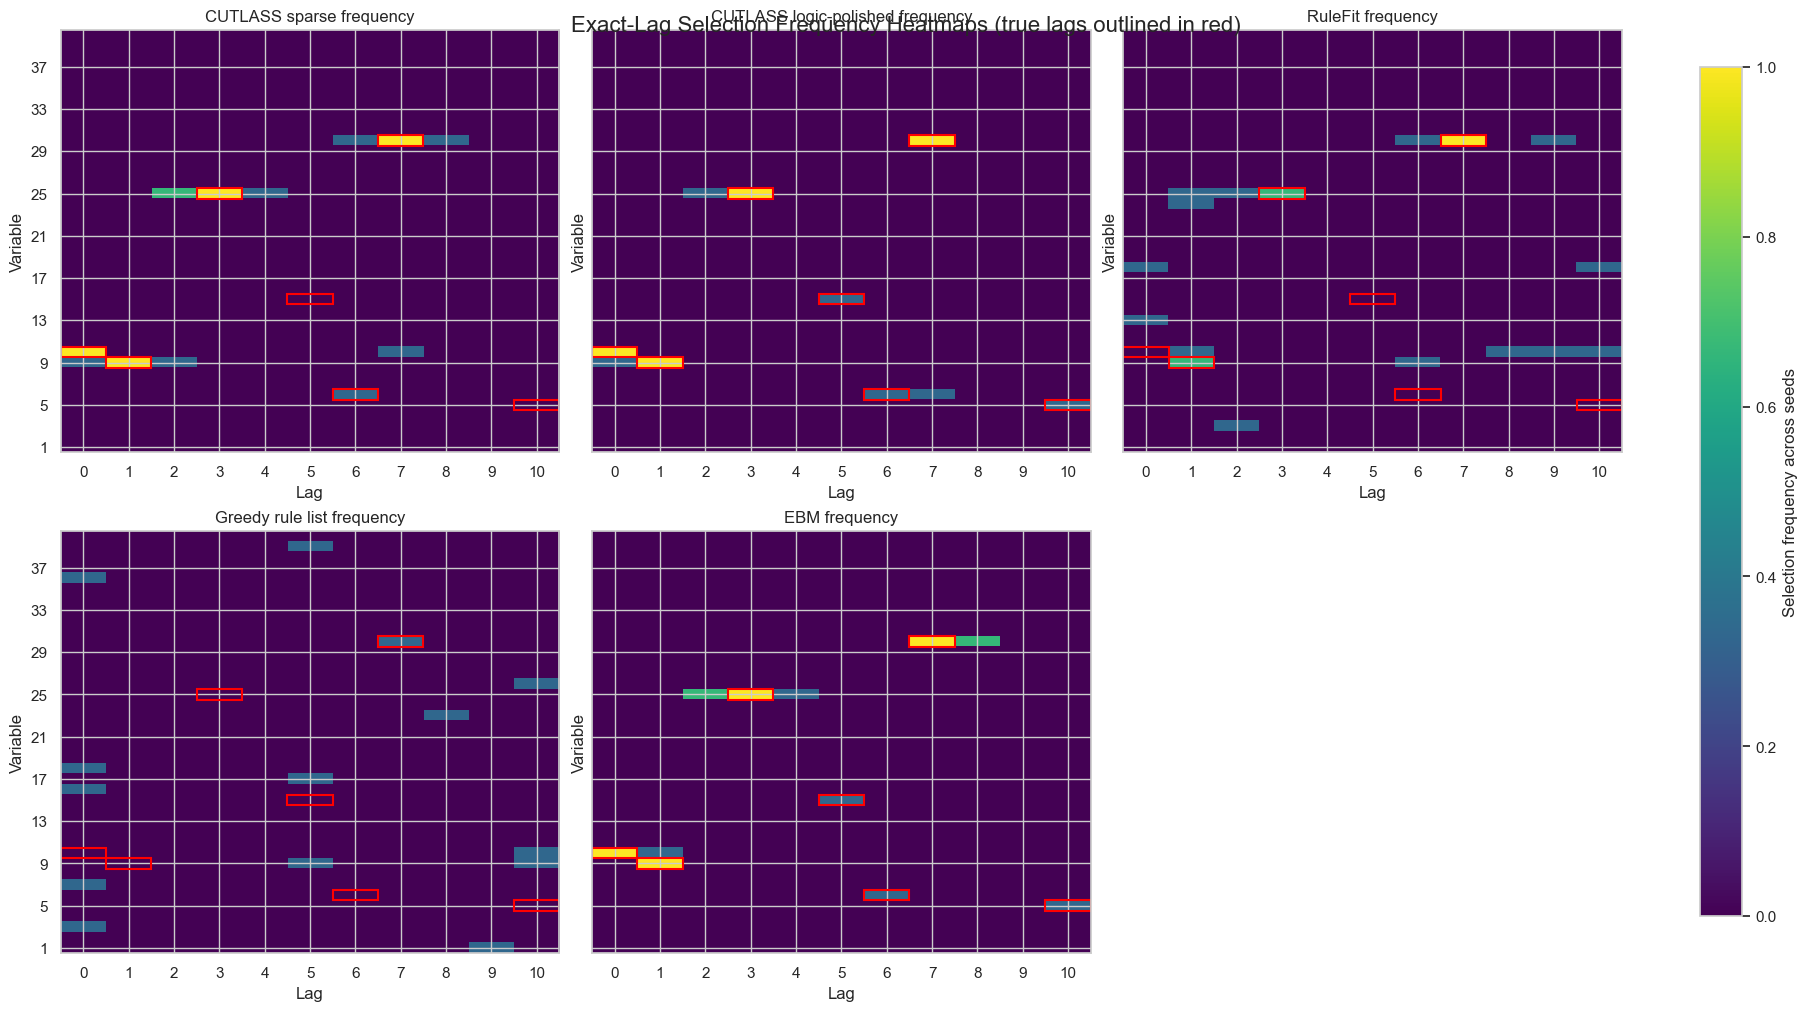

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\interpretable_baselines_selection_frequency.png


In [9]:
heatmap_supports = {}
for method in METHOD_ORDER:
    method_df = runs_df.loc[runs_df["method"] == method].copy()
    heatmap_supports[method] = [decode_support(value) for value in method_df["selected_features"].tolist()]

heatmap_grids = {
    method: support_frequency_grid(supports, n_variables=SYN_CONFIG["S"], h=SYN_CONFIG["H"])
    for method, supports in heatmap_supports.items()
}

for method, grid in heatmap_grids.items():
    pd.DataFrame(grid).to_csv(RUN_DIR / f"selection_frequency_{method}.csv", index=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True, constrained_layout=True)
axes = axes.ravel()
image = None
for ax, method in zip(axes, METHOD_ORDER):
    grid = heatmap_grids[method]
    image = ax.imshow(grid, aspect="auto", origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_title(f"{METHOD_LABELS[method]} frequency")
    ax.set_xlabel("Lag")
    ax.set_xticks(range(SYN_CONFIG["H"] + 1))
    ax.set_ylabel("Variable")
    ax.set_yticks(np.arange(0, SYN_CONFIG["S"], 4))
    ax.set_yticklabels(np.arange(1, SYN_CONFIG["S"] + 1, 4))

    for feature in TRUE_FEATURES:
        parsed = parse_feature(feature)
        if parsed is None:
            continue
        variable, lag = parsed
        ax.add_patch(
            Rectangle(
                (lag - 0.5, variable - 1 - 0.5),
                1,
                1,
                fill=False,
                edgecolor="red",
                linewidth=1.5,
            )
        )

for ax in axes[len(METHOD_ORDER):]:
    ax.axis("off")

cbar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.92)
cbar.set_label("Selection frequency across seeds")
fig.suptitle("Exact-Lag Selection Frequency Heatmaps (true lags outlined in red)", fontsize=16, y=0.99)
fig.savefig(LAG_HEATMAP_PATH, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", LAG_HEATMAP_PATH)


## Dual View: Comparable Support vs. Full Active Support

The previous heatmap keeps every method on the same visual footing by showing only the top-`K` exact-lag locations used for comparison. That is useful for benchmarking, but it is not the same as asking what a reviewer would have to interpret in practice. The panel below therefore adds a second view that uses each model's full active support. This makes dense additive or rule chatter visible without changing the original comparable heatmap, and it highlights that CUTLASS logic is the one method here that also returns a native rule size `k` rather than requiring a post hoc display cutoff.


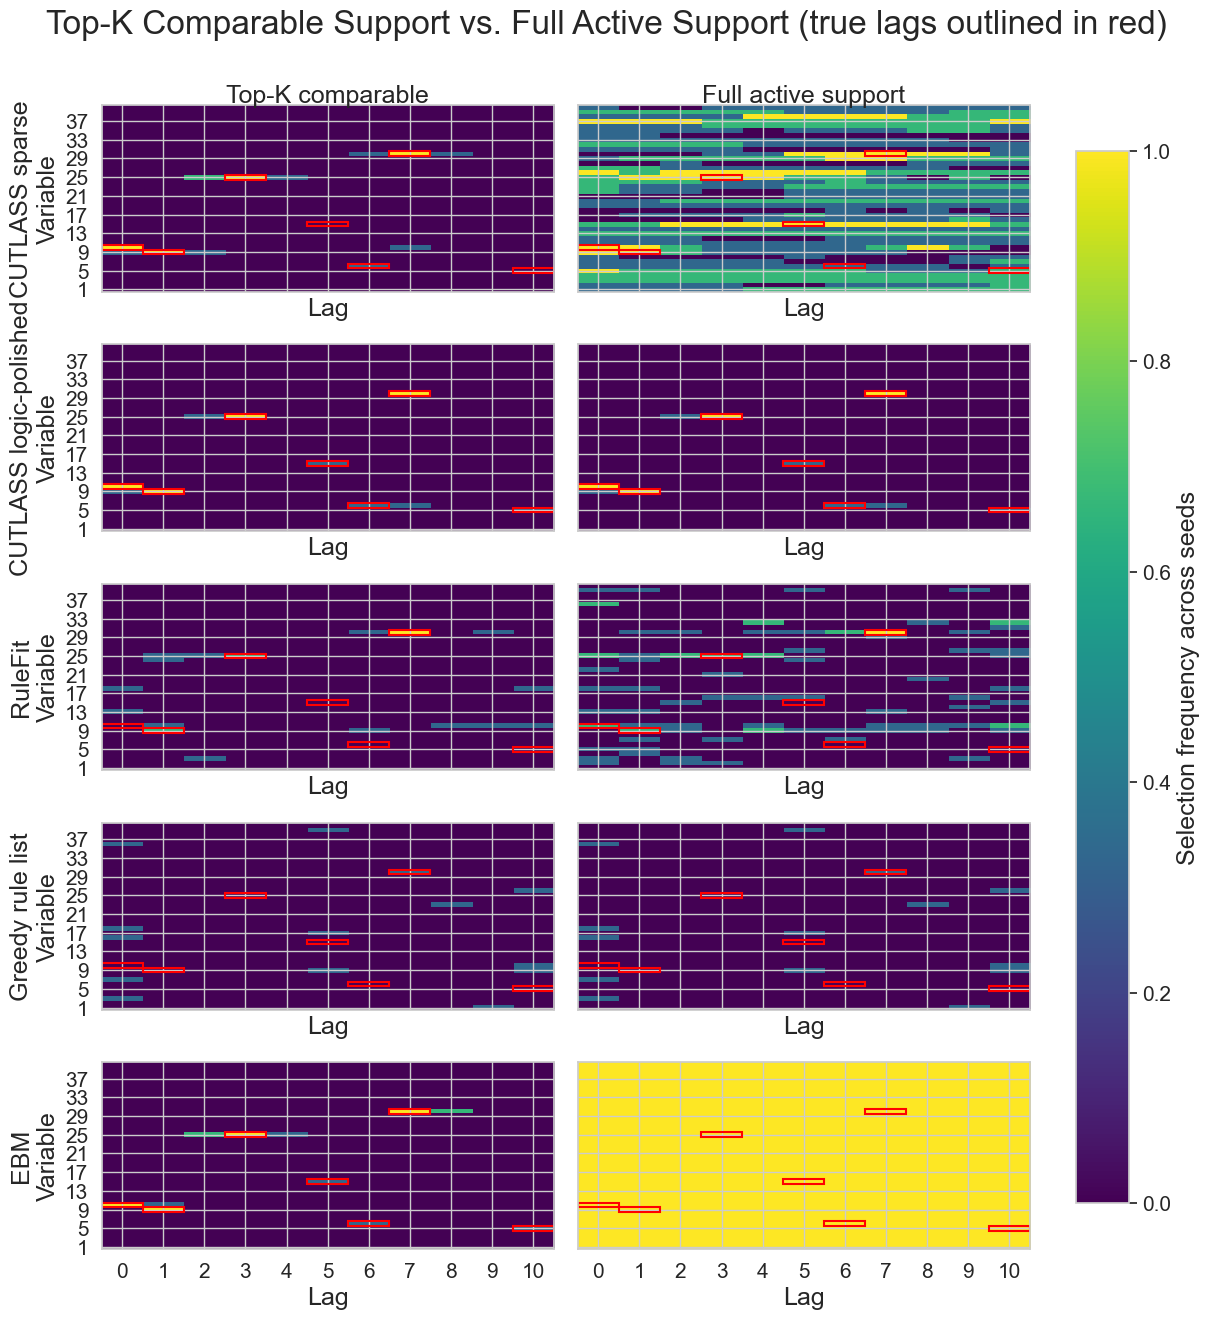

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\interpretable_baselines_dual_support_frequency.png


In [10]:
full_supports = {}
for method in METHOD_ORDER:
    method_df = runs_df.loc[runs_df["method"] == method].copy()
    full_supports[method] = [decode_support(value) for value in method_df["full_support_features"].tolist()]

full_heatmap_grids = {
    method: support_frequency_grid(supports, n_variables=SYN_CONFIG["S"], h=SYN_CONFIG["H"])
    for method, supports in full_supports.items()
}

for method, grid in full_heatmap_grids.items():
    pd.DataFrame(grid).to_csv(RUN_DIR / f"selection_frequency_full_{method}.csv", index=False)

panel_title_size = 18
panel_title_pad = 2
axis_label_size = 18
tick_label_size = 15
colorbar_label_size = 18
suptitle_size = 24

fig, axes = plt.subplots(len(METHOD_ORDER), 2, figsize=(12, 2.5 * len(METHOD_ORDER)), sharex=True, sharey=True, constrained_layout=True)
fig.set_constrained_layout_pads(h_pad=0.12, w_pad=0.04, hspace=0.04, wspace=0.04)
image = None
for row_idx, method in enumerate(METHOD_ORDER):
    views = [
        ("Top-K comparable", heatmap_grids[method]),
        ("Full active support", full_heatmap_grids[method]),
    ]
    for col_idx, (view_name, grid) in enumerate(views):
        ax = axes[row_idx, col_idx]
        image = ax.imshow(grid, aspect="auto", origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        if row_idx == 0:
            ax.set_title(view_name, fontsize=panel_title_size, pad=panel_title_pad)
        ax.set_xlabel("Lag", fontsize=axis_label_size)
        if col_idx == 0:
            ax.set_ylabel(f"{METHOD_LABELS[method]}\nVariable", fontsize=axis_label_size)
        ax.set_xticks(range(SYN_CONFIG["H"] + 1))
        ax.set_yticks(np.arange(0, SYN_CONFIG["S"], 4))
        ax.set_yticklabels(np.arange(1, SYN_CONFIG["S"] + 1, 4))
        ax.tick_params(axis="both", labelsize=tick_label_size)
        for feature in TRUE_FEATURES:
            parsed = parse_feature(feature)
            if parsed is None:
                continue
            variable, lag = parsed
            ax.add_patch(
                Rectangle(
                    (lag - 0.5, variable - 1 - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="red",
                    linewidth=1.5,
                )
            )

cbar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.92)
cbar.set_label("Selection frequency across seeds", fontsize=colorbar_label_size)
cbar.ax.tick_params(labelsize=tick_label_size)
fig.suptitle("Top-K Comparable Support vs. Full Active Support (true lags outlined in red)", fontsize=suptitle_size, y=1.05)
fig.savefig(DUAL_SUPPORT_HEATMAP_PATH, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", DUAL_SUPPORT_HEATMAP_PATH)


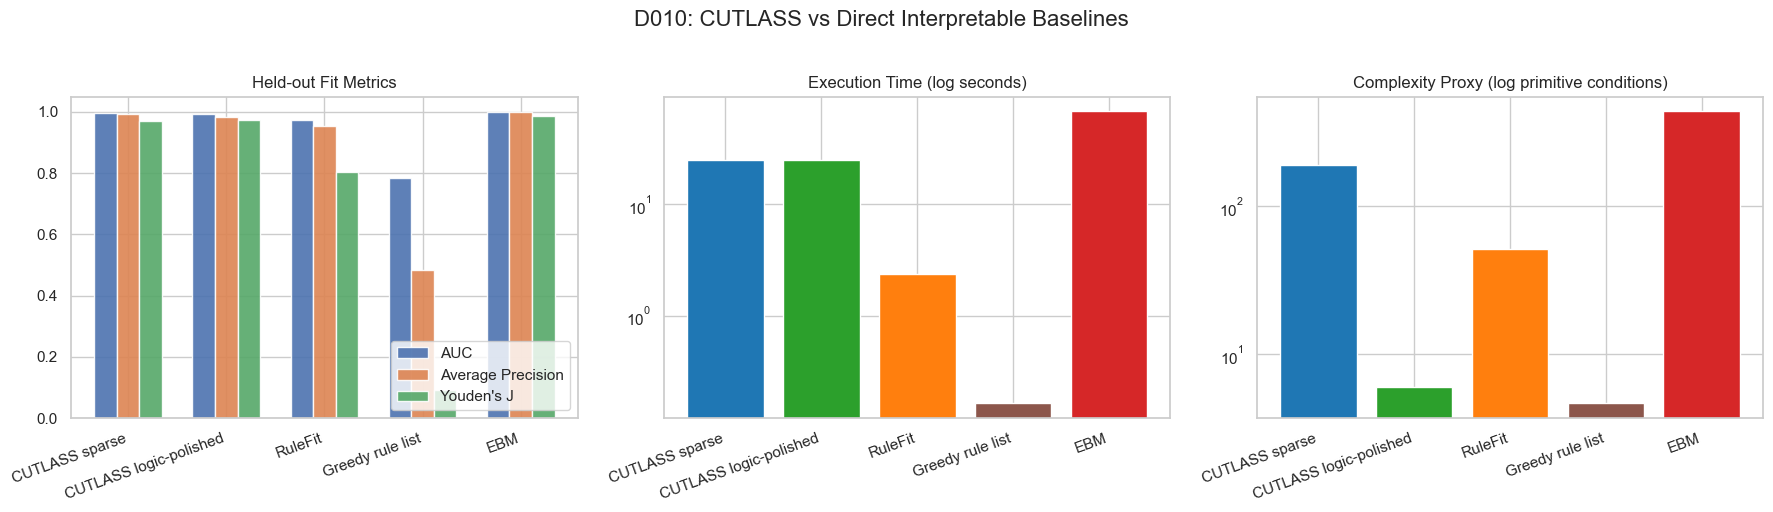

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\interpretable_baselines_case1_summary.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(summary_df))
colors = [METHOD_COLORS[method] for method in summary_df["method"]]

width = 0.23
fit_metrics = [
    ("auc_test_mean", "AUC", -width),
    ("ap_test_mean", "Average Precision", 0.0),
    ("j_test_mean", "Youden's J", width),
]
for metric_name, label, offset in fit_metrics:
    axes[0].bar(
        x + offset,
        summary_df[metric_name].to_numpy(dtype=float),
        width=width,
        label=label,
        alpha=0.9,
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_df["method_label"], rotation=20, ha="right")
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title("Held-out Fit Metrics")
axes[0].legend(loc="lower right")

axes[1].bar(x, summary_df["total_seconds_mean"].to_numpy(dtype=float), color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_df["method_label"], rotation=20, ha="right")
axes[1].set_yscale("log")
axes[1].set_title("Execution Time (log seconds)")

axes[2].bar(x, summary_df["primitive_conditions_mean"].to_numpy(dtype=float), color=colors)
axes[2].set_xticks(x)
axes[2].set_xticklabels(summary_df["method_label"], rotation=20, ha="right")
axes[2].set_yscale("log")
axes[2].set_title("Complexity Proxy (log primitive conditions)")

fig.suptitle("D010: CUTLASS vs Direct Interpretable Baselines", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", FIGURE_PATH)


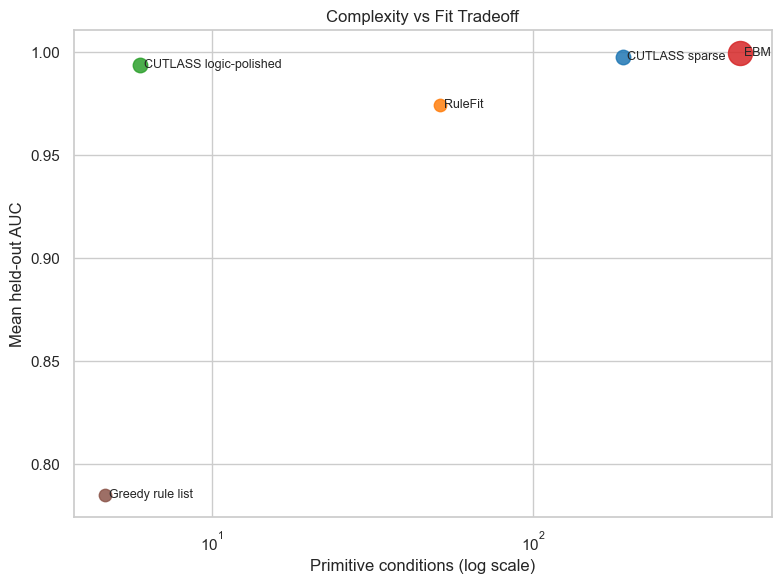

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\interpretable_baselines_case1_tradeoff.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
for row in summary_df.itertuples():
    ax.scatter(
        float(row.primitive_conditions_mean),
        float(row.auc_test_mean),
        s=max(80.0, 300.0 * float(row.total_seconds_mean) / max(summary_df["total_seconds_mean"].max(), 1e-9)),
        color=METHOD_COLORS[row.method],
        alpha=0.85,
        label=row.method_label,
    )
    ax.text(
        float(row.primitive_conditions_mean) * 1.03,
        float(row.auc_test_mean),
        row.method_label,
        fontsize=9,
        va="center",
    )
ax.set_xscale("log")
ax.set_xlabel("Primitive conditions (log scale)")
ax.set_ylabel("Mean held-out AUC")
ax.set_title("Complexity vs Fit Tradeoff")
fig.tight_layout()
fig.savefig(TRADEOFF_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", TRADEOFF_FIGURE_PATH)


In [13]:
best_auc_row = summary_df.loc[summary_df["auc_test_mean"].idxmax()]
fastest_row = summary_df.loc[summary_df["total_seconds_mean"].idxmin()]
smallest_complexity_row = summary_df.loc[summary_df["primitive_conditions_mean"].idxmin()]
cutlass_logic_row = summary_df.loc[summary_df["method"] == "cutlass_logic"].iloc[0]
cutlass_sparse_row = summary_df.loc[summary_df["method"] == "cutlass_sparse"].iloc[0]

takeaways = [
    (
        f"{best_auc_row['method_label']} has the strongest mean held-out AUC in this standardized package "
        f"({best_auc_row['auc_test_mean']:.3f})."
    ),
    (
        f"{fastest_row['method_label']} is the fastest fit in the package at about "
        f"{fastest_row['total_seconds_mean']:.3f} seconds total."
    ),
    (
        f"{smallest_complexity_row['method_label']} has the smallest primitive-complexity proxy "
        f"({smallest_complexity_row['primitive_conditions_mean']:.1f})."
    ),
    (
        f"CUTLASS logic polishing reduces the average primitive count from "
        f"{cutlass_sparse_row['primitive_conditions_mean']:.1f} to "
        f"{cutlass_logic_row['primitive_conditions_mean']:.1f}, with mean AUC moving from "
        f"{cutlass_sparse_row['auc_test_mean']:.3f} to {cutlass_logic_row['auc_test_mean']:.3f}."
    ),
]
if pd.notna(cutlass_logic_row["adopted_rate"]):
    takeaways.append(
        f"The CUTLASS logic-polished candidate is formally adopted under its own policy on "
        f"{cutlass_logic_row['adopted_rate']:.3f} of the synthetic seeds in this notebook."
    )

TAKEAWAYS_PATH.write_text("\n".join(f"- {line}" for line in takeaways) + "\n", encoding="utf-8")
render_markdown("### D010 Takeaways\n" + "\n".join(f"- {line}" for line in takeaways))
print("Saved:", TAKEAWAYS_PATH)


### D010 Takeaways
- EBM has the strongest mean held-out AUC in this standardized package (1.000).
- Greedy rule list is the fastest fit in the package at about 0.165 seconds total.
- Greedy rule list has the smallest primitive-complexity proxy (4.7).
- CUTLASS logic polishing reduces the average primitive count from 190.0 to 6.0, with mean AUC moving from 0.998 to 0.994.

Saved: C:\Users\jason\ODU\dissertation\notebooks\runs_new\interpretable_baselines\case1_interpretable_takeaways.txt


## Artifact Summary

The notebook writes the core artifacts to:

- `notebooks/runs_new/interpretable_baselines/case1_interpretable_runs.csv`
- `notebooks/runs_new/interpretable_baselines/case1_interpretable_summary.csv`
- `notebooks/runs_new/interpretable_baselines/case1_interpretable_summary_formatted.csv`
- `notebooks/runs_new/interpretable_baselines/case1_interpretable_takeaways.txt`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_cutlass_sparse.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_cutlass_logic.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_rulefit.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_greedy_rulelist.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_ebm.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_full_cutlass_sparse.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_full_cutlass_logic.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_full_rulefit.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_full_greedy_rulelist.csv`
- `notebooks/runs_new/interpretable_baselines/selection_frequency_full_ebm.csv`

and saves figures into `notebooks/Figures/`:

- `interpretable_baselines_case1_summary.png`
- `interpretable_baselines_case1_tradeoff.png`
- `interpretable_baselines_selection_frequency.png`
- `interpretable_baselines_dual_support_frequency.png`
